# Comparison: Feb 2026 vs Mar 2026 ML Results

Compares two consolidated summary files to describe how model performance changed between runs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

FILE_OLD = "../../analysis/results/consolidated/combined_summary_with_dispersion_2026-02-03_2051_2026-02-03_2053_2026-02-05_2206_2026-02-06_0905_2026-02-07_0100.csv"
FILE_NEW = "../../analysis/results/consolidated/combined_summary_with_dispersion_2026-03-06_2028_2026-03-07_1213.csv"

KEY = ["model", "target", "dataset"]
METRICS = ["mae", "mse"]

df_old = pd.read_csv(FILE_OLD)
df_new = pd.read_csv(FILE_NEW)

merged = df_old.merge(df_new, on=KEY, suffixes=("_old", "_new"))
assert len(merged) == len(df_old) == len(df_new), f"Alignment failed: {len(merged)} rows merged"
print(f"{len(merged)} rows aligned successfully")
merged.head(3)

88 rows aligned successfully


,model,r2_old,mse_old,mae_old,y_true_old,y_pred_old,target,dataset,sd_y_true_old,iqr_y_true_old,p_value_mae_old,r2_new,mse_new,mae_new,y_true_new,y_pred_new,sd_y_true_new,iqr_y_true_new,p_value_mae_new
0,RandomForestRegressor,-0.031470,2.481419,1.306021,"[-2.57, -1.35, 1.96, -2.4, 0.89, -1.64, 0.61, ...","[-0.362733728305731, -0.3213538686715882, 0.54...",sensibilidad,tmt_dprime,1.554655,2.47000,0.076923,-0.046293,2.517078,1.310963,"[-2.57, -1.35, 1.96, -2.4, 0.89, -1.64, 0.61, ...","[-0.4490538767057552, -0.3086489180797194, 0.4...",1.554655,2.47000,0.136863
1,RandomForestRegressor,0.043593,0.491841,0.566098,"[1.1, 3.135, 3.9000000000000004, 2.5, 3.465, 1...","[2.494386831515488, 2.636100059523809, 2.92082...",K_mean,tmt_k_mean,0.719119,0.93875,0.002997,0.010049,0.509091,0.573369,"[1.1, 3.135, 3.9000000000000004, 2.5, 3.465, 1...","[2.770319860930737, 2.720470238095239, 2.85399...",0.719119,0.93875,0.010989
2,RandomForestRegressor,-0.115545,2952.228661,42.644893,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[240.1243797445866, 230.65971466919598, 224.62...",ssrt,tmt_ssrt,51.595577,62.25000,0.999001,-0.079481,2856.786481,41.924162,"[235, 132, 205, 94, 175, 213, 255, 270, 201, 2...","[242.22392280954432, 230.65971466919592, 224.6...",51.595577,62.25000,0.938062


## 1. Compute Deltas

In [2]:
for m in METRICS:
    merged[f"delta_{m}"] = merged[f"{m}_new"] - merged[f"{m}_old"]

merged["delta_p"] = merged["p_value_mae_new"] - merged["p_value_mae_old"]

# mae lower = better
merged["improved_mae"] = merged["delta_mae"] < 0

# Significance flip (threshold 0.05)
merged["sig_old"] = merged["p_value_mae_old"] < 0.05
merged["sig_new"] = merged["p_value_mae_new"] < 0.05
merged["sig_flipped"] = merged["sig_old"] != merged["sig_new"]

print(f"Combinations with improved MAE: {merged['improved_mae'].sum()} / {len(merged)}")
print(f"Significance status changed:    {merged['sig_flipped'].sum()} / {len(merged)}")

Combinations with improved MAE: 44 / 88
Significance status changed:    6 / 88


## 2. Overall Summary Table (sorted by |ΔMAE|)

In [3]:
summary_cols = KEY + [
    "mae_old", "mae_new", "delta_mae",
    "p_value_mae_old", "p_value_mae_new",
    "sig_old", "sig_new", "sig_flipped"
]
summary = merged[summary_cols].copy()
summary = summary.sort_values("delta_mae", key=abs, ascending=False)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 88)
summary.reset_index(drop=True)

,model,target,dataset,mae_old,mae_new,delta_mae,p_value_mae_old,p_value_mae_new,sig_old,sig_new,sig_flipped
0,RandomForestRegressor,ssrt,tmt_ssrt,42.6449,41.9242,-0.7207,0.9990,0.9381,False,False,False
1,XGBRegressor,ssrt,tmt_ssrt,44.8185,44.3570,-0.4615,0.5614,0.2667,False,False,False
2,LinearRegression,ssrt,tmt_ssrt,45.0791,44.8443,-0.2349,0.9680,0.9281,False,False,False
3,SVR,ssrt,tmt_ssrt,39.9979,39.9150,-0.0829,0.7962,0.6334,False,False,False
4,XGBRegressor,age,tmt_age,7.6878,7.6130,-0.0748,0.0010,0.0010,True,True,False
5,Ridge,ssrt,tmt_ssrt,40.2614,40.1867,-0.0748,0.9950,0.9780,False,False,False
6,RandomForestRegressor,age,tmt_age,7.3899,7.3306,-0.0592,0.0010,0.0010,True,True,False
7,SVR,age,tmt_age,6.8363,6.7822,-0.0542,0.0010,0.0010,True,True,False
8,XGBRegressor,K_6,tmt_k6,0.8335,0.8777,0.0442,0.0020,0.0779,True,False,True
9,XGBRegressor,sensibilidad,tmt_dprime,1.4286,1.3861,-0.0425,0.4845,0.1259,False,False,False


## 3. Breakdown by Model

In [4]:
by_model = merged.groupby("model").agg(
    mean_mae_old=("mae_old", "mean"),
    mean_mae_new=("mae_new", "mean"),
    mean_delta_mae=("delta_mae", "mean"),
    n_improved_mae=("improved_mae", "sum"),
    n_datasets=("dataset", "count"),
).sort_values("mean_delta_mae", ascending=True)

by_model

,mean_mae_old,mean_mae_new,mean_delta_mae,n_improved_mae,n_datasets
model,,,,,
RandomForestRegressor,4.9805,4.9075,-0.0730,9,11
XGBRegressor,5.2304,5.1875,-0.0429,5,11
LinearRegression,5.1989,5.1841,-0.0148,2,11
SVR,4.6867,4.6720,-0.0148,9,11
Ridge,4.7275,4.7181,-0.0094,7,11
Lasso,4.7376,4.7361,-0.0015,5,11
DummyRegressor,4.7756,4.7756,0.0000,0,11
ElasticNet,4.7215,4.7238,0.0023,7,11


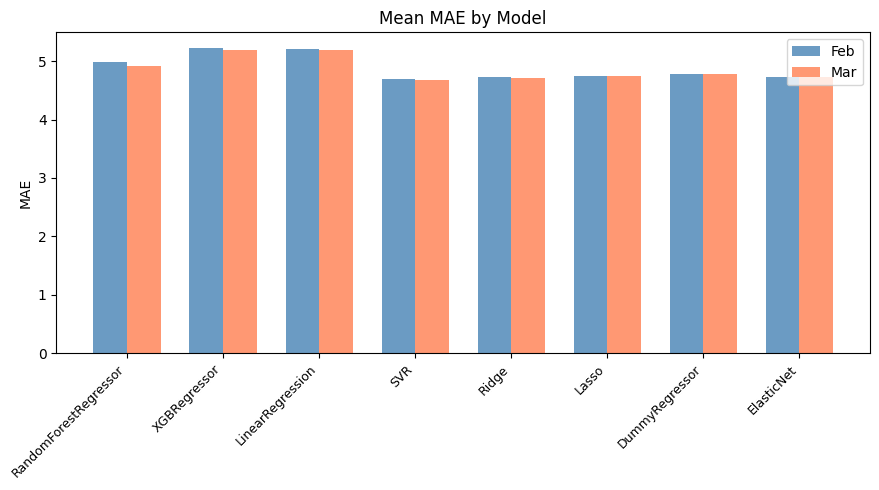

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

models = by_model.index
x = np.arange(len(models))
w = 0.35

ax.bar(x - w/2, by_model["mean_mae_old"], w, label="Feb", color="steelblue", alpha=0.8)
ax.bar(x + w/2, by_model["mean_mae_new"], w, label="Mar", color="coral", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right", fontsize=9)
ax.set_title("Mean MAE by Model")
ax.set_ylabel("MAE")
ax.legend()

plt.tight_layout()
plt.show()

## 4. Breakdown by Target

In [6]:
by_target = merged.groupby("target").agg(
    mean_mae_old=("mae_old", "mean"),
    mean_mae_new=("mae_new", "mean"),
    mean_delta_mae=("delta_mae", "mean"),
    n_improved_mae=("improved_mae", "sum"),
    n_datasets=("dataset", "count"),
).sort_values("mean_delta_mae", ascending=True)

by_target

,mean_mae_old,mean_mae_new,mean_delta_mae,n_improved_mae,n_datasets
target,,,,,
ssrt,41.6644,41.4708,-0.1935,5,8
age,7.2652,7.2404,-0.0247,6,8
sensibilidad,1.3309,1.3255,-0.0054,5,8
K_4,0.4929,0.4921,-0.0008,5,8
accuracy,0.0783,0.0777,-0.0006,5,8
FA,0.1087,0.1090,0.0004,3,8
K_6,0.8138,0.8142,0.0004,9,16
eficiencia,0.1129,0.1137,0.0008,2,8
c,0.4502,0.4525,0.0022,2,8


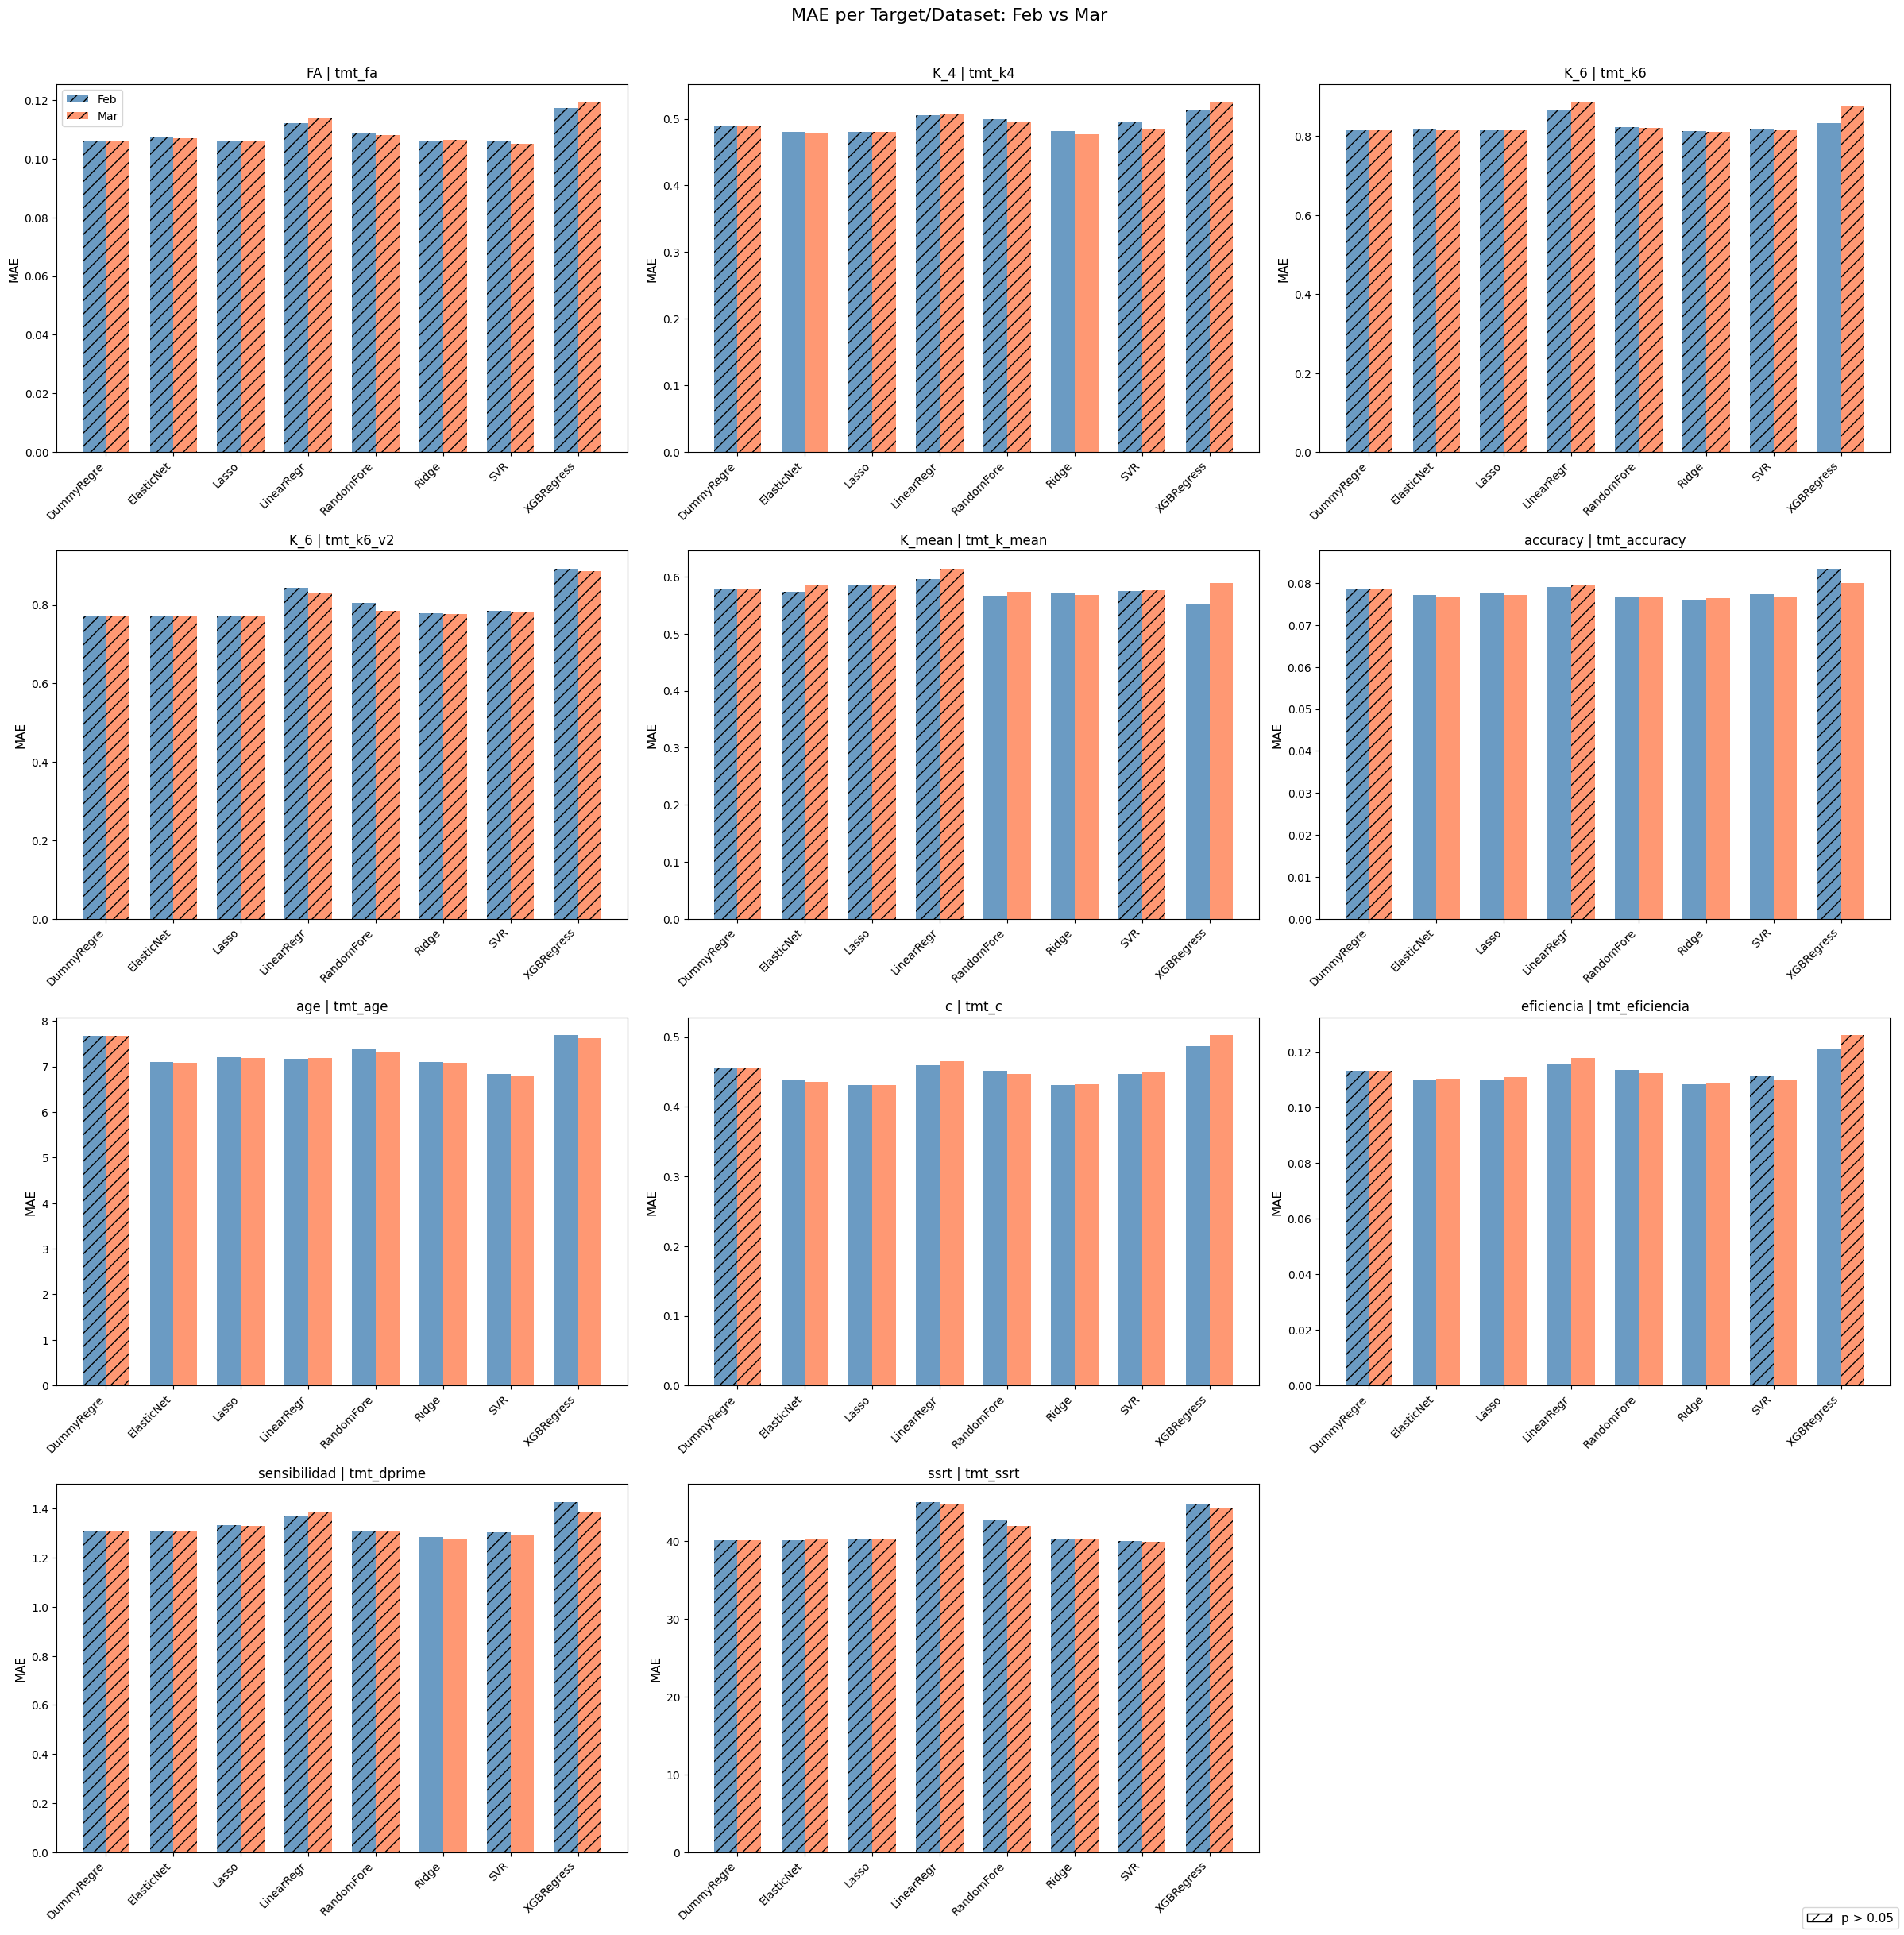

Imagen guardada: mae_per_target_feb_vs_mar.png


In [7]:
combos = (
    merged[["target", "dataset"]]
    .drop_duplicates()
    .sort_values(["target", "dataset"])
    .values.tolist()
)
n_combos = len(combos)
ncols = 3
nrows = int(np.ceil(n_combos / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(24, nrows * 6))
axes = axes.flatten()

models_order = sorted(merged["model"].unique())
x = np.arange(len(models_order))
w = 0.35

P_THRESHOLD = 0.05

for i, (target, dataset) in enumerate(combos):
    ax = axes[i]
    sub = (
        merged[(merged["target"] == target) & (merged["dataset"] == dataset)]
        .set_index("model")
        [["mae_old", "mae_new", "p_value_mae_old", "p_value_mae_new"]]
        .reindex(models_order)
    )
    for j, model in enumerate(models_order):
        row = sub.loc[model]
        hatch_old = "//" if row["p_value_mae_old"] > P_THRESHOLD else None
        hatch_new = "//" if row["p_value_mae_new"] > P_THRESHOLD else None
        ax.bar(x[j] - w/2, row["mae_old"], w, label="Feb" if j == 0 else "", color="steelblue", alpha=0.8, hatch=hatch_old)
        ax.bar(x[j] + w/2, row["mae_new"], w, label="Mar" if j == 0 else "", color="coral",     alpha=0.8, hatch=hatch_new)

    ax.set_title(f"{target} | {dataset}", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([m[:10] for m in models_order], rotation=45, ha="right", fontsize=10)
    ax.set_ylabel("MAE", fontsize=11)
    if i == 0:
        ax.legend(fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

hatch_patch = mpatches.Patch(facecolor="white", edgecolor="black", hatch="//", label=f"p > {P_THRESHOLD}")
fig.legend(handles=[hatch_patch], loc="lower right", fontsize=11)

plt.suptitle("MAE per Target/Dataset: Feb vs Mar", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("mae_per_target_feb_vs_mar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Imagen guardada: mae_per_target_feb_vs_mar.png")

## 5. ΔMAE Heatmap (Model × Target)

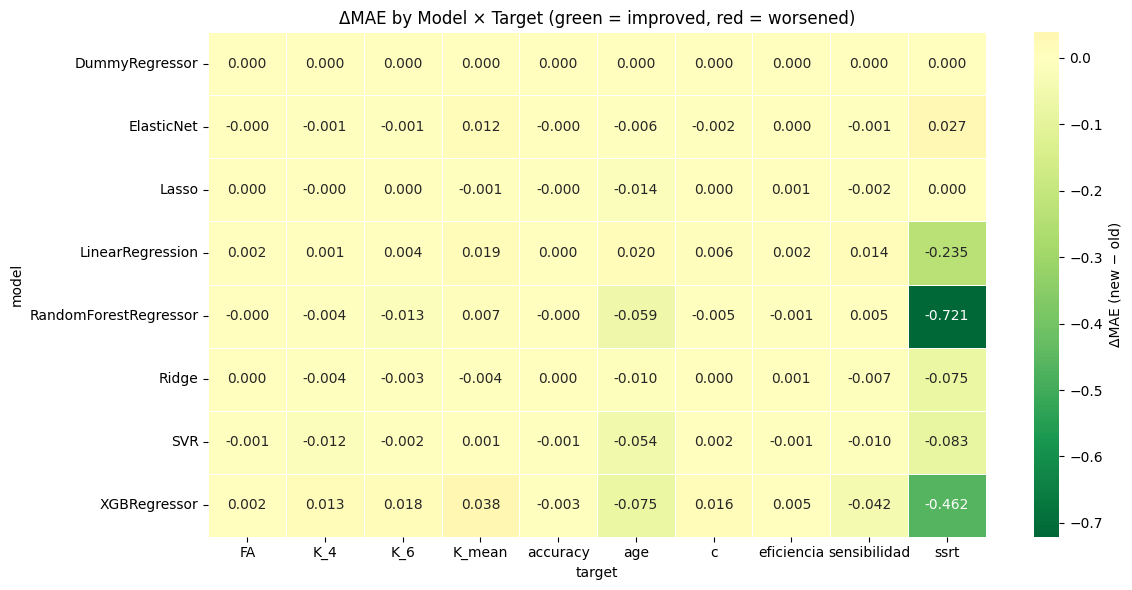

In [8]:
pivot = merged.pivot_table(index="model", columns="target", values="delta_mae")

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "ΔMAE (new − old)"}
)
ax.set_title("ΔMAE by Model × Target (green = improved, red = worsened)", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Statistical Significance Changes (p_value_mae)

In [9]:
flipped = merged[merged["sig_flipped"]][["model", "target", "dataset",
                                         "p_value_mae_old", "sig_old",
                                         "p_value_mae_new", "sig_new"]]
flipped = flipped.sort_values("target")
print(f"Combinations where significance status flipped: {len(flipped)}")
flipped.reset_index(drop=True)

Combinations where significance status flipped: 6


,model,target,dataset,p_value_mae_old,sig_old,p_value_mae_new,sig_new
0,XGBRegressor,K_6,tmt_k6,0.0020,True,0.0779,False
1,LinearRegression,accuracy,tmt_accuracy,0.0400,True,0.0529,False
2,XGBRegressor,accuracy,tmt_accuracy,0.1269,False,0.0150,True
3,XGBRegressor,eficiencia,tmt_eficiencia,0.0210,True,0.1628,False
4,SVR,eficiencia,tmt_eficiencia,0.0829,False,0.0280,True
5,SVR,sensibilidad,tmt_dprime,0.0709,False,0.0320,True


## 7. Summary Narrative

In [10]:
n = len(merged)
n_imp_mae = merged["improved_mae"].sum()
n_sig_flip = merged["sig_flipped"].sum()

best_idx = merged["delta_mae"].idxmin()   # lower MAE = better
worst_idx = merged["delta_mae"].idxmax()  # higher MAE = worse
best = merged.loc[best_idx]
worst = merged.loc[worst_idx]

gained_sig = merged[merged["sig_flipped"] & merged["sig_new"]]
lost_sig = merged[merged["sig_flipped"] & ~merged["sig_new"]]

print("=" * 60)
print("SUMMARY: Feb 2026 → Mar 2026")
print("=" * 60)
print(f"Total model-target-dataset combinations: {n}")
print()
print(f"MAE improved: {n_imp_mae}/{n} ({100*n_imp_mae/n:.1f}%)")
print(f"MAE worsened: {n - n_imp_mae}/{n} ({100*(n - n_imp_mae)/n:.1f}%)")
print()
print(f"Best improvement — {best['model']} on {best['target']} ({best['dataset']}): "
      f"ΔMAE={best['delta_mae']:+.4f} ({best['mae_old']:.4f} → {best['mae_new']:.4f})")
print(f"Biggest decline  — {worst['model']} on {worst['target']} ({worst['dataset']}): "
      f"ΔMAE={worst['delta_mae']:+.4f} ({worst['mae_old']:.4f} → {worst['mae_new']:.4f})")
print()
print(f"Significance flips (p_mae < 0.05): {n_sig_flip} total")
print(f"  Gained significance: {len(gained_sig)}")
print(f"  Lost  significance:  {len(lost_sig)}")
print()
print("Best model overall (mean ΔMAE, lower is better):")
best_model = by_model["mean_delta_mae"].idxmin()
print(f"  {best_model}: {by_model.loc[best_model, 'mean_delta_mae']:+.4f}")
worst_model = by_model["mean_delta_mae"].idxmax()
print(f"Worst model overall (mean ΔMAE):")
print(f"  {worst_model}: {by_model.loc[worst_model, 'mean_delta_mae']:+.4f}")

SUMMARY: Feb 2026 → Mar 2026
Total model-target-dataset combinations: 88

MAE improved: 44/88 (50.0%)
MAE worsened: 44/88 (50.0%)

Best improvement — RandomForestRegressor on ssrt (tmt_ssrt): ΔMAE=-0.7207 (42.6449 → 41.9242)
Biggest decline  — XGBRegressor on K_6 (tmt_k6): ΔMAE=+0.0442 (0.8335 → 0.8777)

Significance flips (p_mae < 0.05): 6 total
  Gained significance: 3
  Lost  significance:  3

Best model overall (mean ΔMAE, lower is better):
  RandomForestRegressor: -0.0730
Worst model overall (mean ΔMAE):
  ElasticNet: +0.0023
